In [23]:
import mujoco
import mediapy
import datetime
import numpy as np
import matplotlib.pyplot as plt

from typing import Callable
from math import ceil
from tqdm.notebook import tqdm

In [17]:
model = mujoco.MjModel.from_xml_path("../robot_models/cart_pole/scene.xml")
data = mujoco.MjData(model)

# avoid rendeder to be black-screened
try:
    renderer
except:
    renderer = mujoco.Renderer(model)

""

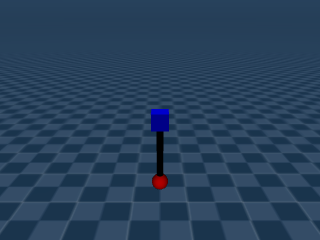

In [18]:
mujoco.mj_step(model, data)
renderer.update_scene(data)

mediapy.show_image(renderer.render())

In [19]:
def get_desc(
    amps: np.ndarray,
    freqs: np.ndarray,
    is_sin: np.ndarray,
    amp_decimal: int,
    freq_decimal: int,
) -> str:
    atoms = []
    for i, (is_sin_now, freq, amp) in enumerate(zip(is_sin, freqs, amps)):
        func = "sin" if is_sin_now else "cos"
        amp = np.round(amp, amp_decimal)
        freq = np.round(freq, freq_decimal)
        if i == 0 and amp <= 0:
            atoms.append("-")
        if i > 0:
            atoms.append(" + " if amp >= 0 else " - ")
        atoms.append(f"{np.abs(amp)} * {func}({freq} * t)")
    return "".join(atoms)


def gen_ctrl(
    length: int,
    max_amp: float = 0.25,
    max_freq: float = 1,
    amp_decimal: int = 3,
    freq_decimal: int = 2,
) -> tuple[Callable[[float], float], str]:
    amps = np.round((np.random.rand(length) - 0.5) * max_amp * 2, decimals=amp_decimal)
    freqs = np.round((np.random.rand(length) - 0.5) * max_freq * 2, decimals=freq_decimal)
    is_sin = np.random.randint(0, 2, size=length)

    def _ctrl(_t: float) -> float:
        res = 0.0
        for is_sin_now, freq, amp in zip(is_sin, freqs, amps):
            res += (amp * np.sin(freq * _t)) if is_sin_now else (amp * np.cos(freq * _t))
        return res

    return _ctrl, get_desc(amps, freqs, is_sin, amp_decimal, freq_decimal)


np.random.seed(457)
ctrls_1 = []
ctrls_2 = []
ctrls_desc_1 = []
ctrls_desc_2 = []
N = 100

for i in range(N):
    ctrl_1, ctrl_1_desc = gen_ctrl(3, max_amp=0.3)
    ctrl_2, ctrl_2_desc = gen_ctrl(3, max_amp=0.4)
    ctrls_1.append(ctrl_1)
    ctrls_2.append(ctrl_2)
    ctrls_desc_1.append(ctrl_1_desc)
    ctrls_desc_2.append(ctrl_2_desc)

for ctrl_1_desc, ctrl_2_desc in zip(ctrls_desc_1, ctrls_desc_2):
    print("ctrl_1 =", ctrl_1_desc)
    print("ctrl_2 =", ctrl_2_desc)
    print()

ctrl_1 = -0.191 * sin(0.1 * t) - 0.106 * cos(0.47 * t) - 0.22 * sin(-0.8 * t)
ctrl_2 = 0.149 * cos(-0.62 * t) + 0.262 * sin(0.54 * t) - 0.036 * cos(0.23 * t)

ctrl_1 = 0.27 * cos(0.06 * t) + 0.175 * cos(-0.88 * t) - 0.297 * cos(-0.39 * t)
ctrl_2 = 0.384 * sin(-0.97 * t) - 0.31 * sin(0.2 * t) + 0.331 * sin(-0.23 * t)

ctrl_1 = 0.143 * cos(-0.7 * t) + 0.01 * cos(-0.96 * t) + 0.04 * cos(0.39 * t)
ctrl_2 = -0.093 * cos(0.23 * t) - 0.225 * sin(0.1 * t) + 0.184 * cos(-0.9 * t)

ctrl_1 = -0.054 * cos(-0.77 * t) - 0.093 * sin(0.66 * t) - 0.153 * cos(0.42 * t)
ctrl_2 = -0.027 * sin(-0.03 * t) + 0.27 * sin(-0.42 * t) + 0.349 * sin(-0.36 * t)

ctrl_1 = -0.02 * sin(-0.5 * t) - 0.15 * sin(-0.91 * t) + 0.148 * cos(-0.56 * t)
ctrl_2 = 0.039 * sin(0.78 * t) + 0.038 * sin(0.26 * t) + 0.253 * cos(0.3 * t)

ctrl_1 = 0.298 * sin(-0.98 * t) + 0.203 * cos(0.42 * t) + 0.113 * cos(0.16 * t)
ctrl_2 = 0.223 * cos(0.65 * t) - 0.112 * cos(-0.68 * t) - 0.391 * sin(-0.9 * t)

ctrl_1 = 0.215 * cos(-0.61 * t) - 0.017

In [20]:
import os
from pathlib import Path
paths = list(Path("../data/raw/cart_pole/").iterdir())
for path in paths:
    os.remove(path)

In [21]:
np.random.seed(109)
duration = 5  # (seconds)
framerate = 30  # (Hz)
frames = []
rec = Recorder(model)
relax_steps = 3
relax_duration = 0.2


def bound_1(q: float, v: float):
    return -0.1 * q - 0.05 * v


def bound_2(q: float, v: float):
    return -0.2 * q - 0.05 * v


for ctrl_1, ctrl_2 in tqdm(list(zip(ctrls_1, ctrls_2))):
    rec = Recorder(model)
    n_steps = int(ceil(duration * framerate)) + 1
    target_path = (
        f"../data/raw/cart_pole/{datetime.datetime.now().strftime('%Y%m%d%H%M%S%f')}.csv"
    )
    relax_time = np.random.random(relax_steps) * (duration - relax_duration)
    relax_time = np.sort(np.r_[relax_time, relax_time + relax_duration])

    # Simulate and display video.
    frames = []
    mujoco.mj_resetData(model, data)  # Reset state and time.

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultCamera(cam)
    cam.lookat = np.array([0.0, 0.0, 1.0])
    cam.azimuth = -90
    cam.elevation = -20
    cam.distance = 1

    ctrl_on = True
    relax_idx = 0

    while data.time < duration:
        t = data.time
        q1, q2 = data.qpos
        v1, v2 = data.qvel

        if relax_idx < 2 * relax_steps and t >= relax_time[relax_idx]:
            ctrl_on = not ctrl_on
            relax_idx += 1

        if ctrl_on:
            data.ctrl[0] = ctrl_1(t) + bound_1(q1, v1)
            data.ctrl[1] = ctrl_2(t) + bound_2(q2, v2)
        else:
            data.ctrl[0] = 0.0
            data.ctrl[1] = 0.0

        cam.lookat = np.array([q1, 0, 1])
        mujoco.mj_checkPos(model, data)
        mujoco.mj_checkVel(model, data)
        mujoco.mj_forward(model, data)
        mujoco.mj_checkAcc(model, data)
        # record data
        rec.record(data)
        mujoco.mj_step(model, data)

        if len(frames) < data.time * framerate:
            renderer.update_scene(data, cam)
            pixels = renderer.render()
            frames.append(pixels)

    rec.save_df(target_path)

# Last video
mediapy.show_video(frames, fps=framerate)

  0%|          | 0/100 [00:00<?, ?it/s]

This browser does not support the video tag.


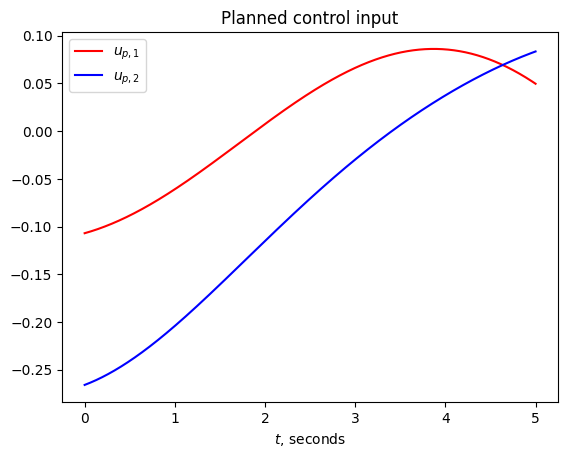

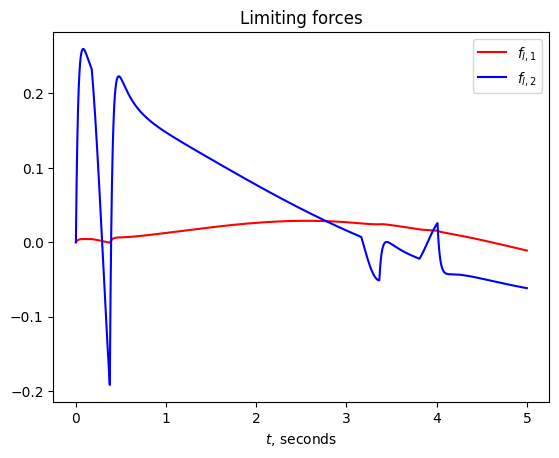

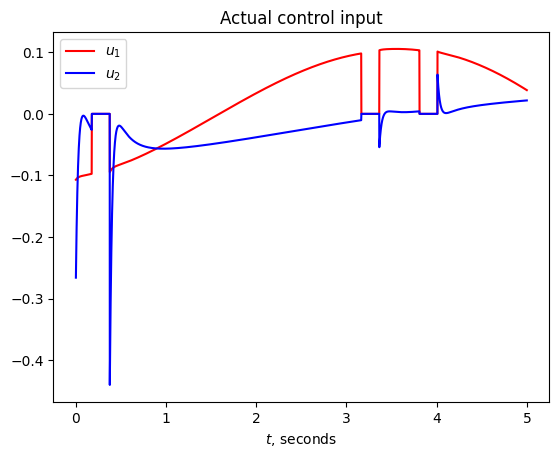

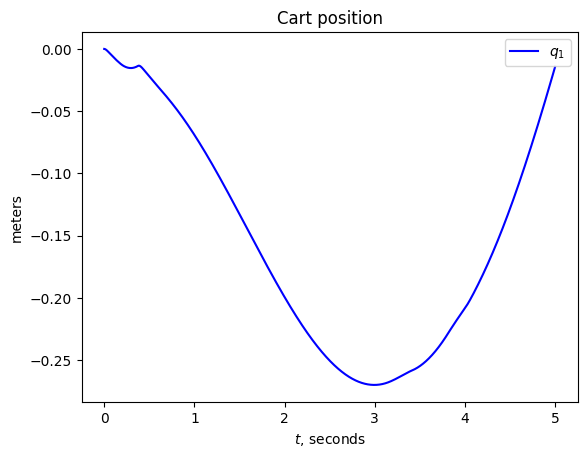

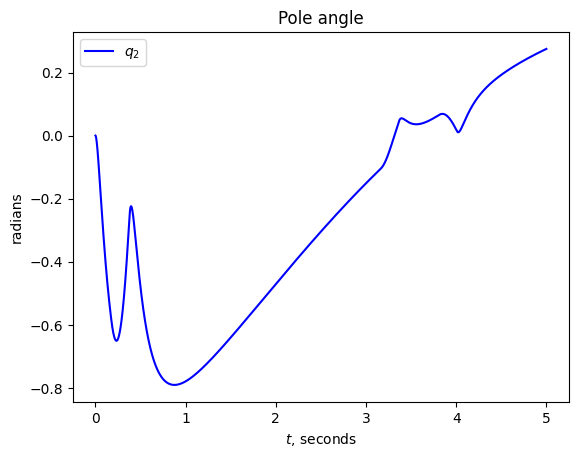

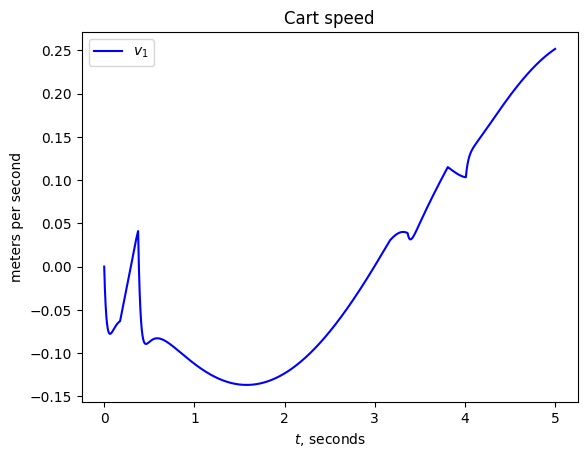

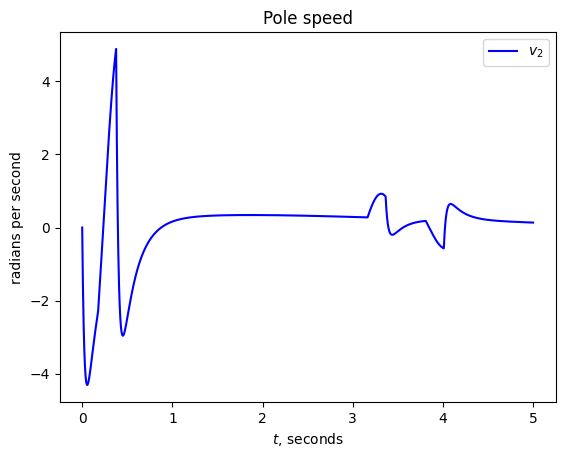

In [22]:
timespan = np.array(rec.history["time"])
ctrls = np.array(rec.history["ctrl"])
q_poses = np.array(rec.history["qpos"])
q_vels = np.array(rec.history["qvel"])

plt.title("Planned control input")
plt.plot(timespan, ctrl_1(timespan), color="red", label="$u_{p, 1}$")
plt.plot(timespan, ctrl_2(timespan), color="blue", label="$u_{p, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Limiting forces")
plt.plot(timespan, bound_1(q_poses[:, 0], q_vels[:, 0]), color="red", label="$f_{l, 1}$")
plt.plot(timespan, bound_2(q_poses[:, 1], q_vels[:, 1]), color="blue", label="$f_{l, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Actual control input")
plt.plot(timespan, ctrls[:, 0], color="red", label="$u_1$")
plt.plot(timespan, ctrls[:, 1], color="blue", label="$u_2$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart position")
plt.plot(timespan, q_poses[:, 0], color="blue", label="$q_1$")
plt.legend(loc="best")
plt.ylabel("meters")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole angle")
plt.plot(timespan, q_poses[:, 1], color="blue", label="$q_2$")
plt.legend(loc="best")
plt.ylabel("radians")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart speed")
plt.plot(timespan, q_vels[:, 0], color="blue", label="$v_1$")
plt.legend(loc="best")
plt.ylabel("meters per second")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole speed")
plt.plot(timespan, q_vels[:, 1], color="blue", label="$v_2$")
plt.legend(loc="best")
plt.ylabel("radians per second")
plt.xlabel("$t$, seconds")
plt.show()